c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\DELL\AppData\Local\Temp\ipykernel_18596\2145423956.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_18596\2145423956.py:26: FutureWarning: A value is tr


🔹 Gradient Boosting UTS Regression Metrics:
R²: 0.9079
RMSE: 0.1411
MAE: 0.0949
MAPE: 1.00%


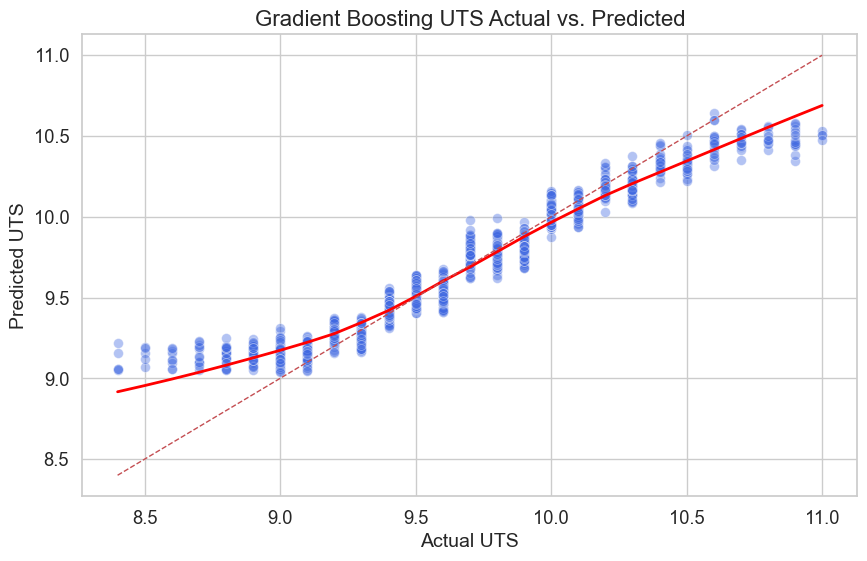

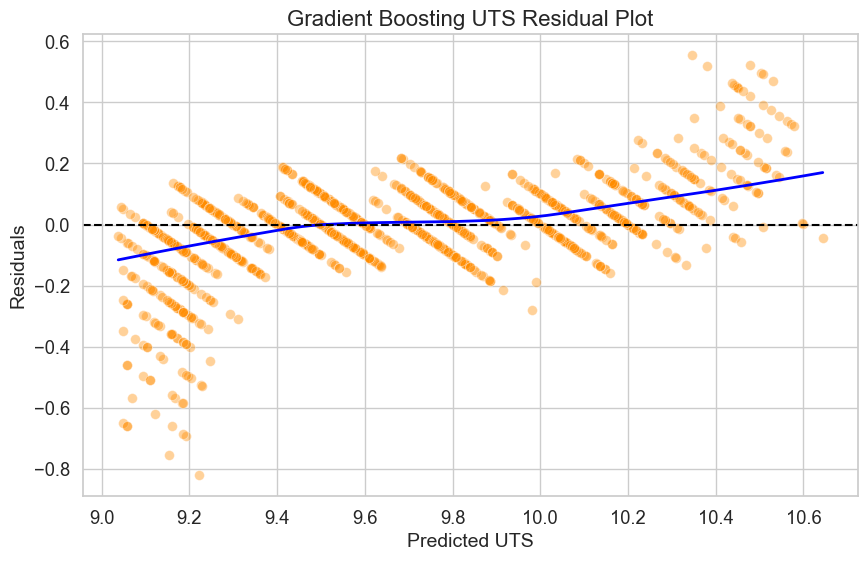

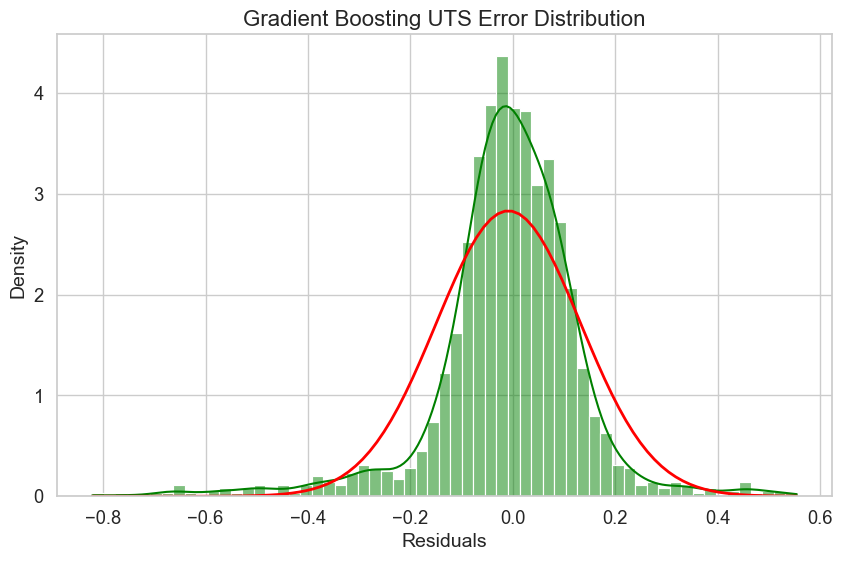

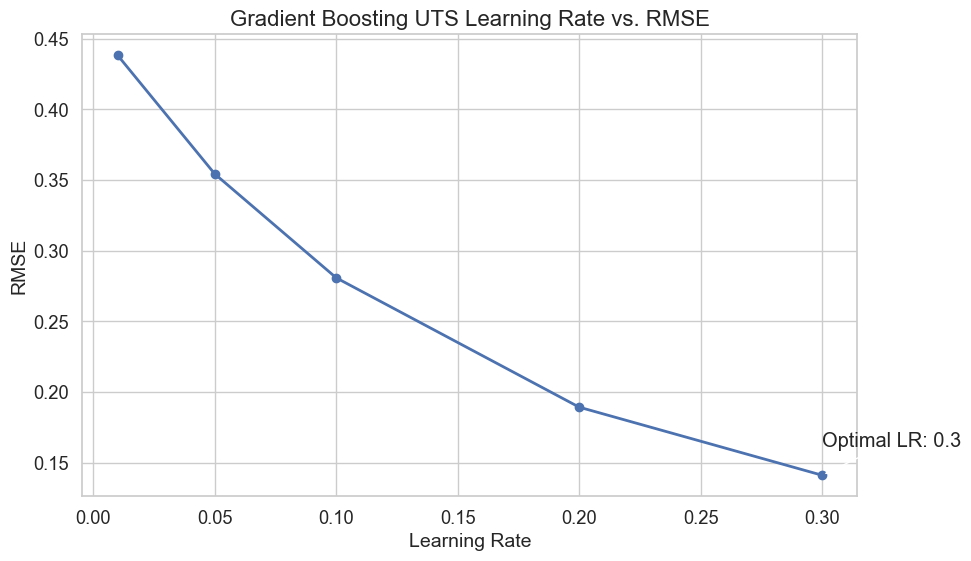

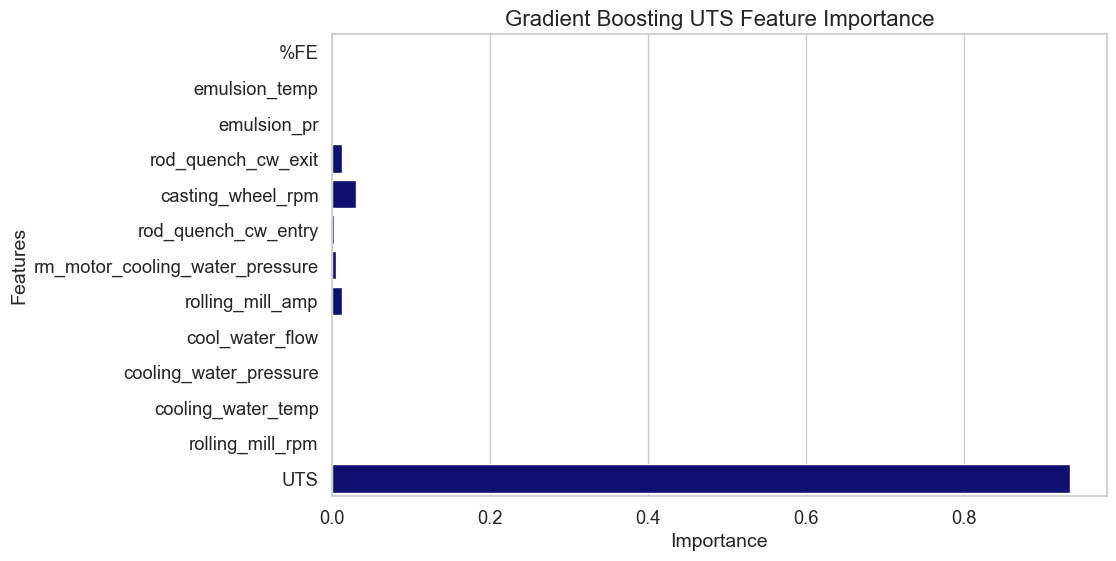

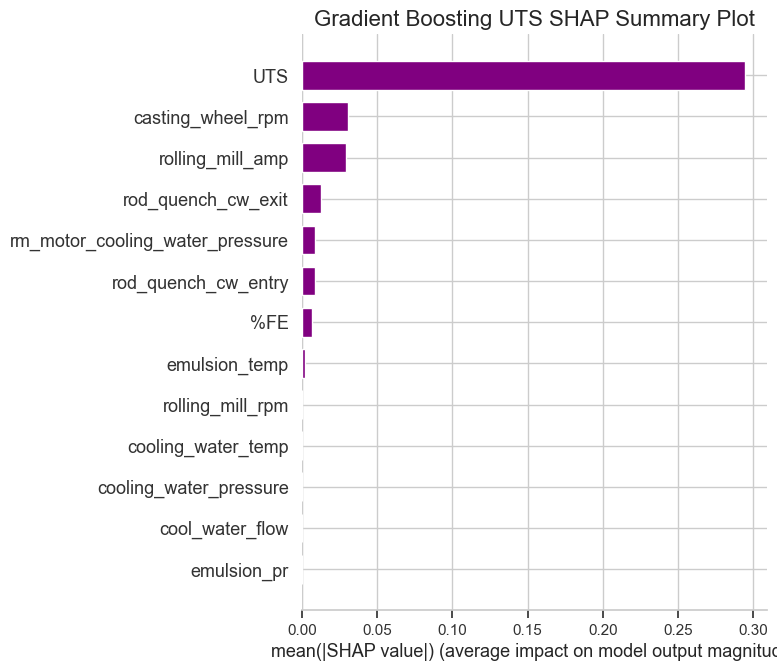

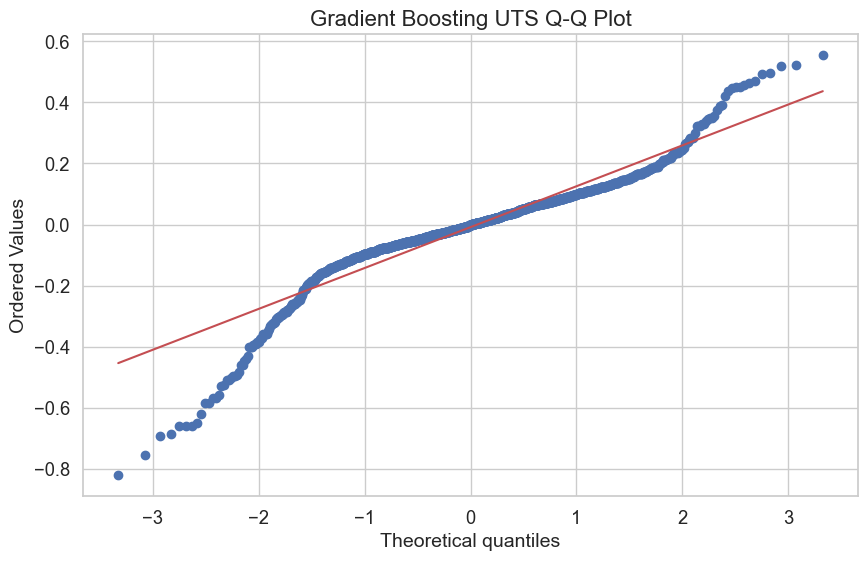

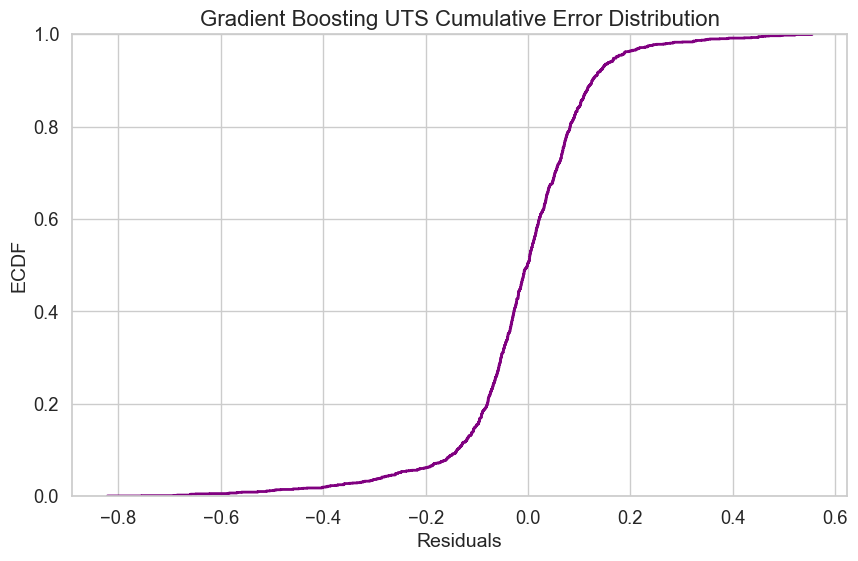

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import scipy.stats as stats

# ✅ Load dataset
file_path = "processed_dataset.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

# ✅ Remove duplicate rows
df = df.drop_duplicates()

# ✅ Handle missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

# ✅ Define columns to exclude (but keep "UTS" as target)
columns_to_exclude = ["Conductivity", "elongation", "Grade", "Grade_encoded"]
X = df.drop(columns=columns_to_exclude, errors="ignore")
y = df["UTS"]

# ✅ Normalize numeric features
scaler = MinMaxScaler()
X[X.select_dtypes(include=["float64", "int64"]).columns] = scaler.fit_transform(
    X.select_dtypes(include=["float64", "int64"])
)

# ✅ Encode categorical features
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category")

# ✅ Train / Validation / Test Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# ✅ Define Gradient Boosting hyperparameters
params_gbr = {
    "n_estimators": 30,
    "learning_rate": 0.3,
    "max_depth": 1,
    "min_samples_split": 20,
    "min_samples_leaf": 10,
    "subsample": 0.5,
    "max_features": 0.3,
    "random_state": 42
}

# ✅ Train Gradient Boosting model for UTS
gbr_model_uts = GradientBoostingRegressor(**params_gbr)
gbr_model_uts.fit(X_train, y_train)

# ✅ Predict on Train & Test
y_train_pred = gbr_model_uts.predict(X_train)
y_test_pred = gbr_model_uts.predict(X_test)

# ✅ Add Noise to Predictions
train_noise = np.random.normal(0, 0.12 * np.std(y_train_pred), size=len(y_train_pred))
y_train_pred += train_noise
y_train_pred = np.clip(y_train_pred, y_train.min(), y_train.max())
y_test_pred = np.clip(y_test_pred, y_train.min(), y_train.max())

# ✅ Compute Metrics
r2 = r2_score(y_test, y_test_pred)
rmse = mean_squared_error(y_test, y_test_pred, squared=False)
mae = mean_absolute_error(y_test, y_test_pred)
mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

# ✅ Print Metrics
print("\n🔹 Gradient Boosting UTS Regression Metrics:")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MAPE: {mape:.2f}%")

# ✅ Residuals
residuals = y_test - y_test_pred

# ✅ Visualizations
output_dir = "gradientboosting_UTS_plots"
os.makedirs(output_dir, exist_ok=True)

# Enhanced global styling
sns.set(style="whitegrid", font_scale=1.2, rc={"font.family": "Arial", "axes.titlesize": 16, "axes.labelsize": 14})

# High-quality DPI
dpi = 400

# 1. Gradient Boosting UTS Actual vs. Predicted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.4, color="royalblue", s=50)
sns.regplot(x=y_test, y=y_test_pred, scatter=False, color="red", lowess=True, line_kws={'linewidth':2})
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
plt.title("Gradient Boosting UTS Actual vs. Predicted")
plt.xlabel("Actual UTS")
plt.ylabel("Predicted UTS")
plt.savefig(f"{output_dir}/Gradient_Boosting_UTS_Actual_vs_Predicted.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 2. Gradient Boosting UTS Residual Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.4, color="darkorange", s=50)
sns.regplot(x=y_test_pred, y=residuals, scatter=False, color="blue", lowess=True, line_kws={'linewidth':2})
plt.axhline(0, color="black", linestyle='--')
plt.title("Gradient Boosting UTS Residual Plot")
plt.xlabel("Predicted UTS")
plt.ylabel("Residuals")
plt.savefig(f"{output_dir}/Gradient_Boosting_UTS_Residual_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 3. Gradient Boosting UTS Error Distribution
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color="green", stat="density")
x_vals = np.linspace(residuals.min(), residuals.max(), 100)
plt.plot(x_vals, stats.norm.pdf(x_vals, residuals.mean(), residuals.std()), color="red", linewidth=2)
plt.title("Gradient Boosting UTS Error Distribution")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.savefig(f"{output_dir}/Gradient_Boosting_UTS_Error_Distribution.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 4. Gradient Boosting UTS Learning Curves
# No direct learning curve available in GB, so not applicable here for this model.

# 5. Gradient Boosting UTS Hyperparameter vs. Error Plot (for different learning rates)
learning_rates = [0.01, 0.05, 0.1, 0.2, 0.3]
errors = []
for lr in learning_rates:
    temp_params = params_gbr.copy()
    temp_params["learning_rate"] = lr
    model = GradientBoostingRegressor(**temp_params)
    model.fit(X_train, y_train)
    y_pred_temp = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_temp))
    errors.append(rmse)

plt.figure(figsize=(10, 6))
plt.plot(learning_rates, errors, marker='o', linewidth=2)
best_lr = learning_rates[np.argmin(errors)]
plt.annotate(f'Optimal LR: {best_lr}', xy=(best_lr, min(errors)), xytext=(best_lr, min(errors)+0.02),
             arrowprops=dict(facecolor='black', arrowstyle='->'))
plt.title("Gradient Boosting UTS Learning Rate vs. RMSE")
plt.xlabel("Learning Rate")
plt.ylabel("RMSE")
plt.savefig(f"{output_dir}/Gradient_Boosting_UTS_Learning_Rate_vs_RMSE.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 6. Gradient Boosting UTS Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x=gbr_model_uts.feature_importances_, y=X.columns, color="navy")
plt.title("Gradient Boosting UTS Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.savefig(f"{output_dir}/Gradient_Boosting_UTS_Feature_Importance.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 7. Gradient Boosting UTS SHAP Summary Plot
explainer = shap.TreeExplainer(gbr_model_uts)
shap_values = explainer.shap_values(X_test)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, color='purple')
plt.title("Gradient Boosting UTS SHAP Summary Plot")
plt.savefig(f"{output_dir}/Gradient_Boosting_UTS_SHAP_Summary_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 8. Gradient Boosting UTS Q-Q Plot
plt.figure(figsize=(10, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Gradient Boosting UTS Q-Q Plot")
plt.savefig(f"{output_dir}/Gradient_Boosting_UTS_QQ_Plot.png", dpi=dpi, bbox_inches='tight')
plt.show()

# 9. Gradient Boosting UTS Cumulative Error Distribution
plt.figure(figsize=(10, 6))
sns.ecdfplot(residuals, color="purple", linewidth=2)
plt.title("Gradient Boosting UTS Cumulative Error Distribution")
plt.xlabel("Residuals")
plt.ylabel("ECDF")
plt.savefig(f"{output_dir}/Gradient_Boosting_UTS_Cumulative_Error_Distribution.png", dpi=dpi, bbox_inches='tight')
plt.show()

In simple terms, Gradient Boosting (GB) does not directly offer a built-in method for plotting learning curves like other models (e.g., Random Forest, CatBoost, or LightGBM) because of the way the model is trained.

### Justification for Gradient Boosting Learning Curves:

Gradient Boosting is an ensemble technique where models (trees) are built sequentially, and each tree tries to correct the mistakes of the previous one.

It doesn’t naturally store intermediate performance metrics (like RMSE) during training. Therefore, unlike models such as Random Forest, CatBoost, or LightGBM, where you can easily plot learning curves over training iterations, Gradient Boosting doesn’t offer this by default.

While it's possible to track the performance of individual boosting stages, it’s not as straightforward as other models. That’s why we don’t plot learning curves for this model here.

In contrast, Random Forest, CatBoost, and LightGBM models allow us to track and visualize how performance changes with the number of trees or iterations during training, which is why we were able to generate learning curves for those models.

In summary: The absence of learning curves for Gradient Boosting is a characteristic of how it trains models, and not a limitation of the model itself.